# Лабораторная работа 6 - Введение в методы оптимизации.

## Условный экстремум при ограничениях-неравенствах

## 1. Цель работы
Исследование необходимых и достаточных условий существования условного экстремума функции при ограничениях типа неравенств. Вычисление экстремумов функции.









##Код
### 2. Определение целевой функции и ограничений



$$
f(x) = -(x_1-x_2)^2 + (x_1+x_2-2)^4 - 10 \to \text{extr}
$$

Ограничения:

$$
g_1(x) = x_1^2 + x_2^2 - 1 \le 0,\quad
g_2(x) = -x_1 \le 0,\quad
g_3(x) = -x_2 \le 0,\quad x\in\mathbb{R}^2.
$$

Область – четверть единичного круга в первом квадранте.

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

x1, x2 = sp.symbols('x1 x2', real=True)

f = -(x1 - x2)**2 + (x1 + x2 - 2)**4 - 10
g1 = x1**2 + x2**2 - 1
g2 = -x1
g3 = -x2

df = sp.Matrix([sp.diff(f, x1), sp.diff(f, x2)])
dg = [None, sp.Matrix([sp.diff(g1, x1), sp.diff(g1, x2)]),
            sp.Matrix([sp.diff(g2, x1), sp.diff(g2, x2)]),
            sp.Matrix([sp.diff(g3, x1), sp.diff(g3, x2)])]
g = [None, g1, g2, g3]

### 3. Метод перебора комбинаций активных ограничений


Будем считать активные ограничения равенствами $g_j(x)=0$, а пассивные – строгими неравенствами.
Для каждого подмножества $A\subseteq\{1,2,3\}$ решаем систему:

$$
\nabla f + \sum_{j\in A} \lambda_j \nabla g_j = 0,\qquad g_j(x)=0\;(j\in A).
$$

Затем проверяем:
- Для минимума $\lambda_j\ge 0$, для максимума $\lambda_j\le 0$ для всех $j\in A$.
- Пассивные ограничения $g_k(x)\le 0$ для $k\notin A$.
- Достаточные условия второго порядка: знак $d^2L$ на ядре активных градиентов.mbda_0=1$) и вырожденный случай $\lambda_0=0$.

In [ ]:
# Начальные приближения (равномерная сетка в допустимой области + углы + центр)
initial_guesses = []
for a in np.linspace(0, 1, 5):
    for b in np.linspace(0, 1, 5):
        if a**2 + b**2 <= 1.01:
            initial_guesses.append((a, b))
# Добавим специфические точки
initial_guesses += [(0.7, 0.7), (0.9, 0.1), (0.1, 0.9), (0.5, 0.5), (0.2, 0.8)]

solutions = []

for active in [[], [1], [2], [3], [1,2], [1,3], [2,3], [1,2,3]]:
    lambdas = {j: sp.symbols(f'l{j}') for j in active}
    # Уравнения: ∇f + Σ λ_j ∇g_j = 0, и g_j = 0 для j∈active
    grad_eq = df.copy()
    for j in active:
        grad_eq += lambdas[j] * dg[j]
    eqs = [sp.Eq(grad_eq[0], 0), sp.Eq(grad_eq[1], 0)]
    for j in active:
        eqs.append(sp.Eq(g[j], 0))

    # Численное решение для каждого начального приближения
    for (x0, y0) in initial_guesses:
        # Начальные значения для λ – небольшие положительные (для min) или нули
        init_vals = {x1: x0, x2: y0}
        for j in active:
            init_vals[lambdas[j]] = 0.5  # начальное положительное
        try:
            sol = sp.nsolve(eqs, list(init_vals.keys()), list(init_vals.values()),
                            tol=1e-14, maxsteps=100, prec=50)
        except Exception:
            continue
        # Проверка вещественности и сохранение
        if all(v.is_real for v in sol):
            x_sol = (float(sol[0]), float(sol[1]))
            l_vals = {j: float(sol[2 + k]) for k, j in enumerate(active)}
            # Отсев дубликатов (по расстоянию)
            if not any(np.sqrt((x_sol[0]-s['x'][0])**2 + (x_sol[1]-s['x'][1])**2) < 1e-6
                       and s['active'] == active for s in solutions):
                solutions.append({'x': x_sol, 'active': active, 'lambdas': l_vals})

### 4. Классификация по знакам множителей и второму дифференциалу

Теперь для каждой допустимой точки проверяем, может ли она быть минимумом или максимумом,
и подтверждаем достаточными условиями второго порядка.

In [ ]:
def check_second_order(x_val, active, lambdas):
    # Классическая функция Лагранжа (λ0=1)
    L = f
    for j, lam in lambdas.items():
        L += lam * g[j]
    H = sp.hessian(L, (x1, x2))
    H_num = np.array(H.subs({x1: x_val[0], x2: x_val[1],
                             **{sp.symbols(f'l{j}'): lam for j, lam in lambdas.items()}})).astype(np.float64)

    # Градиенты активных ограничений
    grads = []
    for j in active:
        grad = np.array([float(dg[j][0].subs({x1: x_val[0], x2: x_val[1]})),
                         float(dg[j][1].subs({x1: x_val[0], x2: x_val[1]}))])
        grads.append(grad)
    if not grads:
        eig = np.linalg.eigvals(H_num)
        if np.all(eig > 1e-12): return 'min'
        elif np.all(eig < -1e-12): return 'max'
        else: return 'saddle'

    A = np.array(grads)
    U, s, Vt = np.linalg.svd(A)
    tol = 1e-9
    rank = np.sum(s > tol)
    nullity = 2 - rank
    if nullity == 0:
        return 'boundary_point'
    null_basis = Vt[rank:, :].T
    H_proj = null_basis.T @ H_num @ null_basis
    eig = np.linalg.eigvals(H_proj)
    if np.all(eig > 1e-12): return 'min'
    elif np.all(eig < -1e-12): return 'max'
    else: return 'saddle'

extremums = {'min': [], 'max': []}
for s in solutions:
    # Проверка пассивных ограничений
    inactive = set([1,2,3]) - set(s['active'])
    feasible = True
    for j in inactive:
        val = float(g[j].subs({x1: s['x'][0], x2: s['x'][1]}))
        if val > 1e-6:
            feasible = False; break
    if not feasible:
        continue

    l_vals = s['lambdas']
    # Определяем возможный тип по знакам λ
    if all(v >= -1e-12 for v in l_vals.values()):
        cand_type = 'min'
    elif all(v <= 1e-12 for v in l_vals.values()):
        cand_type = 'max'
    else:
        continue

    second = check_second_order(s['x'], s['active'], s['lambdas'])
    if second == cand_type:
        extremums[cand_type].append({**s, 'f': float(f.subs({x1: s['x'][0], x2: s['x'][1]}))})

### 5. Вывод результатов

In [ ]:
print("Найденные точки условного экстремума:")
for typ in ['min', 'max']:
    for s in extremums[typ]:
        print(f"x* = ({s['x'][0]:.6f}, {s['x'][1]:.6f}), тип = {typ}, f(x*) = {s['f']:.6f}")
        print(f"   Активные ограничения: {s['active']}, λ = {s['lambdas']}")

Найденные точки условного экстремума:
x* = (0.181484, 0.983394), тип = min, f(x*) = -10.156652
   Активные ограничения: [1], λ = {1: 1.9999999999999982}
x* = (0.983394, 0.181484), тип = min, f(x*) = -10.156652
   Активные ограничения: [1], λ = {1: 1.9999999999999982}


### 6.График функции в допустимой области

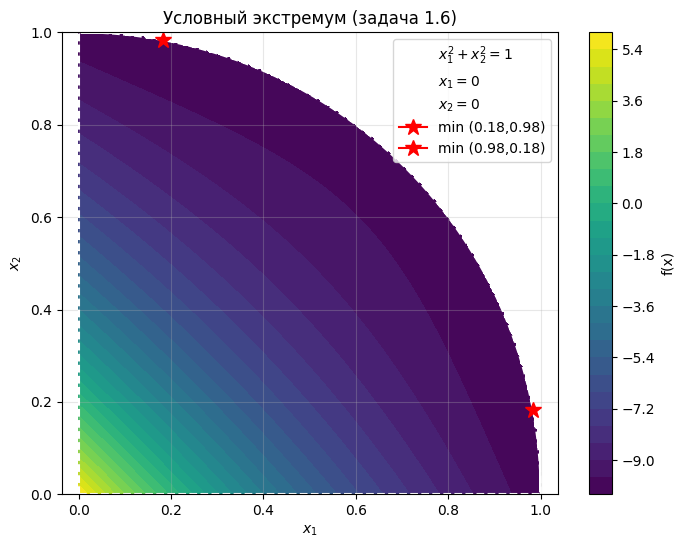

In [ ]:
xs = np.linspace(0, 1, 200)
ys = np.linspace(0, 1, 200)
X, Y = np.meshgrid(xs, ys)
Z = -(X - Y)**2 + (X + Y - 2)**4 - 10
mask = (X>=0) & (Y>=0) & (X**2 + Y**2 <= 1)
Z_masked = np.ma.masked_where(~mask, Z)

plt.figure(figsize=(8,6))
plt.contourf(X, Y, Z_masked, levels=30, cmap='viridis')
plt.colorbar(label='f(x)')
theta = np.linspace(0, np.pi/2, 100)
plt.plot(np.cos(theta), np.sin(theta), 'w--', label='$x_1^2+x_2^2=1$')
plt.plot([0,0],[0,1], 'w--', label='$x_1=0$')
plt.plot([0,1],[0,0], 'w--', label='$x_2=0$')

for typ, marker, color in [('min','*','red'), ('max','*','blue')]:
    for s in extremums[typ]:
        plt.plot(s['x'][0], s['x'][1], marker=marker, color=color, markersize=12,
                 label=f"{typ} ({s['x'][0]:.2f},{s['x'][1]:.2f})")

plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Условный экстремум (задача 1.6)')
plt.legend(loc='upper right')
plt.axis('equal')
plt.xlim(0,1); plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.show()